# Assignment 9
* Student: **Danilo Tambone**
* NetID: **PWC25003**

The work contained and presented here is my work and my work alone.

In [1]:
# import modules

import pandas as pd # for data viz and wrangling
import numpy as np # for 'numeric python'
import matplotlib.pyplot as plt # for data viz (more complex than pylab)
import seaborn as sns
from pylab import * # for data viz (import * means 'import all of the functions')

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn import metrics
from scipy import stats
import statsmodels.api as sm


1. Read in the Telco dataset and determine how many rows and columns it has.


In [2]:
# mount your google drive
from google.colab import drive
drive.mount('/content/drive')

# read data
# on the lefthand side, navigate to your data and copy the path
telco_df = pd.read_csv('/content/drive/MyDrive/Predictive Modeling/M9/Telco_customer_churn.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Determine the shape (rows and columns) exactly as done in the module
rows, cols = telco_df.shape

# Print the results
print(f"The Telco dataset has {rows} rows and {cols} columns.")

The Telco dataset has 7043 rows and 18 columns.


2. Partition the data into a 60/20/20 split.


In [4]:
print(telco_df.head())
print(telco_df.info())

   CustomerID  Gender Senior Citizen Partner Dependents  Tenure Months  \
0  3668-QPYBK    Male             No      No         No              2   
1  9237-HQITU  Female             No      No        Yes              2   
2  9305-CDSKC  Female             No      No        Yes              8   
3  7892-POOKP  Female             No     Yes        Yes             28   
4  0280-XJGEX    Male             No      No        Yes             49   

  Multiple Lines Internet Service Online Security Online Backup  \
0             No              DSL             Yes           Yes   
1             No      Fiber optic              No            No   
2            Yes      Fiber optic              No            No   
3            Yes      Fiber optic              No            No   
4            Yes      Fiber optic              No           Yes   

  Device Protection Tech Support        Contract Paperless Billing  \
0                No           No  Month-to-month               Yes   
1           

In [5]:
#Dropping ID and duplicates columns
df = telco_df.drop(columns=['CustomerID', 'Churn Label'])

In [6]:
# Convert the Y/N to numerical (Yes=1, No=0)
for col in df.columns:
    if df[col].dtype == 'object':
        unique_vals = df[col].unique()
        if set(unique_vals).issubset({'Yes', 'No'}):
            df[col] = df[col].map({'Yes': 1, 'No': 0})

# Display the first few rows
print(df.head(3))

   Gender  Senior Citizen  Partner  Dependents  Tenure Months Multiple Lines  \
0    Male               0        0           0              2             No   
1  Female               0        0           1              2             No   
2  Female               0        0           1              8            Yes   

  Internet Service  Online Security  Online Backup  Device Protection  \
0              DSL                1              1                  0   
1      Fiber optic                0              0                  0   
2      Fiber optic                0              0                  1   

   Tech Support        Contract  Paperless Billing  Electronic Check  \
0             0  Month-to-month                  1                 0   
1             0  Month-to-month                  1                 1   
2             0  Month-to-month                  1                 1   

   Monthly Charges  Churn Value  
0            53.85            1  
1            70.70           

In [7]:
# Apply dummy variables to the remaining categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)

# Display the first few rows
print(df_encoded.head(3))

   Senior Citizen  Partner  Dependents  Tenure Months  Online Security  \
0               0        0           0              2                1   
1               0        0           1              2                0   
2               0        0           1              8                0   

   Online Backup  Device Protection  Tech Support  Paperless Billing  \
0              1                  0             0                  1   
1              0                  0             0                  1   
2              0                  1             0                  1   

   Electronic Check  Monthly Charges  Churn Value  Gender_Male  \
0                 0            53.85            1         True   
1                 1            70.70            1        False   
2                 1            99.65            1        False   

   Multiple Lines_No phone service  Multiple Lines_Yes  \
0                            False               False   
1                            Fals

In [8]:
from sklearn.model_selection import train_test_split

# Define features by dropping the target variable
features = df_encoded.drop(['Churn Value'], axis=1)
target_variable = df_encoded['Churn Value']

# Step 1: Split the data into 80% temporary training and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    features, target_variable, test_size=0.2, random_state=42, stratify=target_variable
)

# Step 2: Split the 80% training data into 60% training and 20% validation
# 0.25 * 0.8 = 0.2
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

# Print the shapes of the resulting datasets
print("Training set shape:  ", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:      ", X_test.shape, y_test.shape)

Training set shape:   (4225, 18) (4225,)
Validation set shape: (1409, 18) (1409,)
Test set shape:       (1409, 18) (1409,)


3. Build a discriminant analysis model to predict churn using all predictors.

In [9]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Initialize the LDA model
lda_model = LinearDiscriminantAnalysis()

# Train the model using the training data
lda_model.fit(X_train, y_train)

print("LDA model trained successfully.")

LDA model trained successfully.


In [10]:
# Get the feature names from X_train
feature_names = X_train.columns

# Get the coefficients from the trained LDA model
coefficients = lda_model.coef_[0]

# Create a pandas Series to associate coefficients with feature names
coef_series = pd.Series(coefficients, index=feature_names)

# Display the coefficients with predictor names
print("Discriminant Function Coefficients:")
print(coef_series)
print("\nIntercept:", lda_model.intercept_[0])

Discriminant Function Coefficients:
Senior Citizen                     0.134671
Partner                            0.235507
Dependents                        -1.140768
Tenure Months                     -0.033077
Online Security                   -0.610129
Online Backup                     -0.399566
Device Protection                 -0.272188
Tech Support                      -0.592264
Paperless Billing                  0.271829
Electronic Check                   0.557459
Monthly Charges                    0.023502
Gender_Male                       -0.044842
Multiple Lines_No phone service    1.032521
Multiple Lines_Yes                 0.241575
Internet Service_Fiber optic       0.473899
Internet Service_No               -0.226220
Contract_One year                 -0.871563
Contract_Two year                 -0.488355
dtype: float64

Intercept: -1.6822560732222254


4. Check model performance by partition with total accuracy, precision, recall, F1 score, and AUC.


Training Set Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.89      0.87      3104
           1       0.66      0.59      0.62      1121

    accuracy                           0.81      4225
   macro avg       0.76      0.74      0.75      4225
weighted avg       0.80      0.81      0.81      4225


Validation Set Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Test Set Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.58      0.61       374

    accuracy                           0.80      1409
   macro avg       0

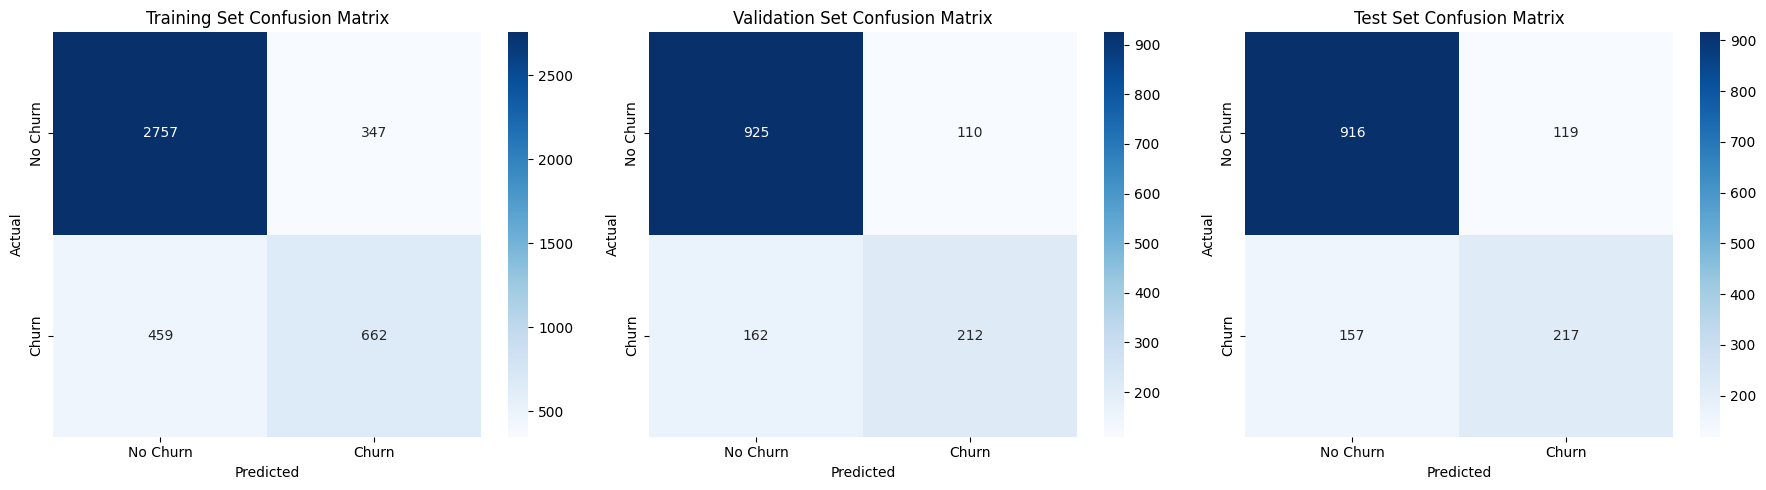

Train AUC: 0.8593
Val AUC: 0.8463
Test AUC: 0.8442


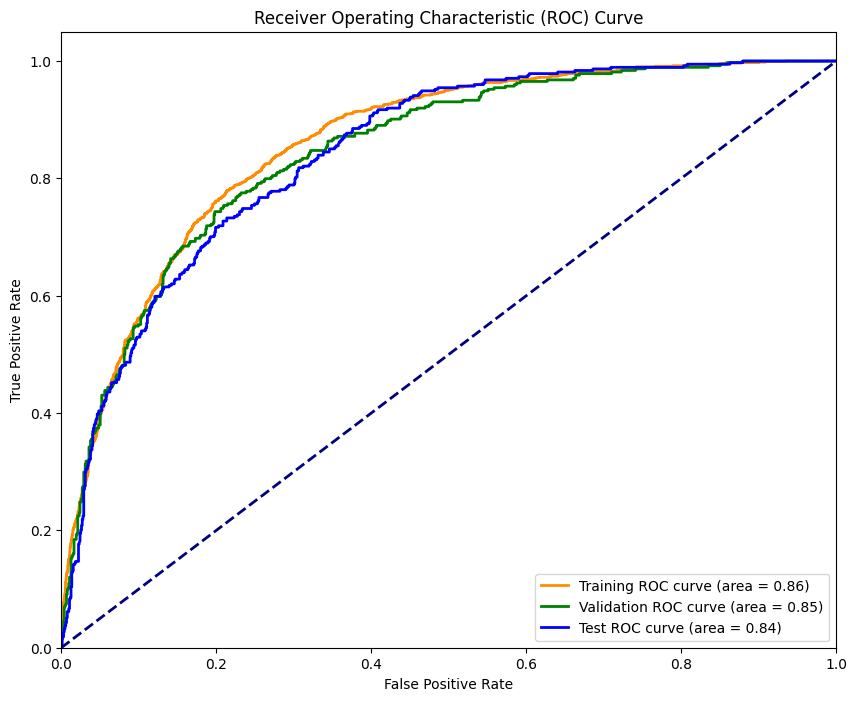

In [11]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the training, validation, and test sets
y_train_pred = lda_model.predict(X_train)
y_val_pred = lda_model.predict(X_val)
y_test_pred = lda_model.predict(X_test)

# Calculate confusion matrices
conf_matrix_train = confusion_matrix(y_train, y_train_pred)
conf_matrix_val = confusion_matrix(y_val, y_val_pred)
conf_matrix_test = confusion_matrix(y_test, y_test_pred)

# Calculate accuracy scores
accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_val = accuracy_score(y_val, y_val_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)

# Print classification reports (includes precision, recall, f1-score, and support)
print("Training Set Classification Report:")
print(classification_report(y_train, y_train_pred))

print("\nValidation Set Classification Report:")
print(classification_report(y_val, y_val_pred))

print("\nTest Set Classification Report:")
print(classification_report(y_test, y_test_pred))


# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(conf_matrix_train, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Training Set Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['No Churn', 'Churn'])
axes[0].set_yticklabels(['No Churn', 'Churn'])


sns.heatmap(conf_matrix_val, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Validation Set Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticklabels(['No Churn', 'Churn'])
axes[1].set_yticklabels(['No Churn', 'Churn'])


sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title('Test Set Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
axes[2].set_xticklabels(['No Churn', 'Churn'])
axes[2].set_yticklabels(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()


# Calculate ROC curves and AUC
y_train_prob = lda_model.predict_proba(X_train)[:, 1]
y_val_prob = lda_model.predict_proba(X_val)[:, 1]
y_test_prob = lda_model.predict_proba(X_test)[:, 1]

fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_train_prob)
roc_auc_train = auc(fpr_train, tpr_train)

fpr_val, tpr_val, thresholds_val = roc_curve(y_val, y_val_prob)
roc_auc_val = auc(fpr_val, tpr_val)

fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_prob)
roc_auc_test = auc(fpr_test, tpr_test)

print(f"Train AUC: {roc_auc_train:.4f}")
print(f"Val AUC: {roc_auc_val:.4f}")
print(f"Test AUC: {roc_auc_test:.4f}")

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2, label='Training ROC curve (area = %0.2f)' % roc_auc_train)
plt.plot(fpr_val, tpr_val, color='green', lw=2, label='Validation ROC curve (area = %0.2f)' % roc_auc_val)
plt.plot(fpr_test, tpr_test, color='blue', lw=2, label='Test ROC curve (area = %0.2f)' % roc_auc_test)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

5. Comment on the model performance.  What did you observe in the results?


The model is very stable and did not overfit. The accuracy stays right around 81% on the training, the validation, and the test data. It proves that the model didn't just memorize the specific customers in the training set. Instead, it actually learned the patterns of churn so it could make good guesses on new customers it had never seen before.

The model is much better at predicting who will stay than who will leave.
It is very accurate at identifying Non-Churners.
It has a harder time with Churners.
The main reason for this is that the dataset has a lot more examples of people who stayed (over 3,000) than people who left (about 1,100). Because the model had more "stay" examples to study, it became an expert at recognizing those customers, while it is still learning how to spot the churners.

A 58% recall means we are catching more than half of the people who are planning to leave. Since human behavior is hard to predict and many different things can make a person quit their phone plan, catching 58% is a solid result. It allows the company to reach out to those customers and try to keep them. While we would like to eventually catch 70% or more, using this model right now will still save the company a lot of money by stopping many customers from leaving.

6. Build a Naïve Bayes model to predict churn using all predictors.


In [12]:
from sklearn.naive_bayes import GaussianNB

# Initialize the Gaussian Naive Bayes model
gnb_model = GaussianNB()

# Train the model using the training data
gnb_model.fit(X_train, y_train)

print("Gaussian Naive Bayes model trained successfully.")

Gaussian Naive Bayes model trained successfully.


7. Check model performance by partition with total accuracy, precision, recall, F1 score, and AUC.

Training Set Classification Report (Naive Bayes):
              precision    recall  f1-score   support

           0       0.91      0.76      0.83      3104
           1       0.54      0.79      0.64      1121

    accuracy                           0.77      4225
   macro avg       0.73      0.77      0.73      4225
weighted avg       0.81      0.77      0.78      4225


Validation Set Classification Report (Naive Bayes):
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.52      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409


Test Set Classification Report (Naive Bayes):
              precision    recall  f1-score   support

           0       0.89      0.75      0.81      1035
           1       0.52      0.75      0.61       374

    accuracy                    

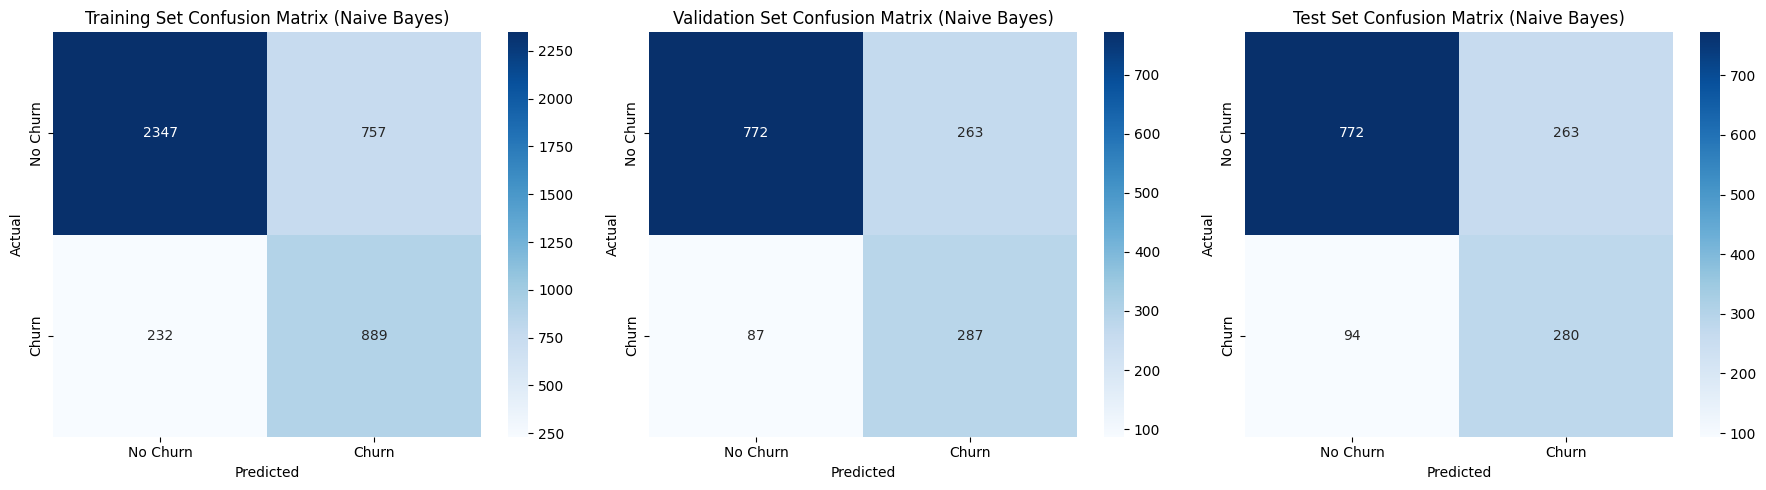

Train AUC: 0.8489
Val AUC: 0.8342
Test AUC: 0.8320


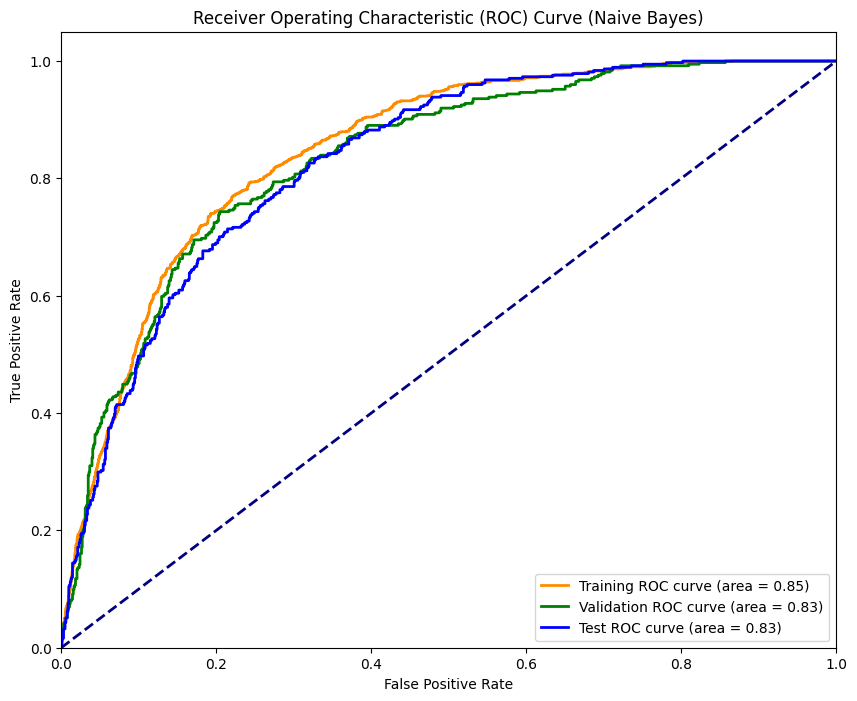

In [13]:
from sklearn.metrics import classification_report

# Make predictions on the training, validation, and test sets
y_train_pred_gnb = gnb_model.predict(X_train)
y_val_pred_gnb = gnb_model.predict(X_val)
y_test_pred_gnb = gnb_model.predict(X_test)

# Print the classification reports
print("Training Set Classification Report (Naive Bayes):")
print(classification_report(y_train, y_train_pred_gnb))

print("\nValidation Set Classification Report (Naive Bayes):")
print(classification_report(y_val, y_val_pred_gnb))

print("\nTest Set Classification Report (Naive Bayes):")
print(classification_report(y_test, y_test_pred_gnb))

from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions and get probabilities on the training, validation, and test sets
y_train_pred_gnb = gnb_model.predict(X_train)
y_val_pred_gnb = gnb_model.predict(X_val)
y_test_pred_gnb = gnb_model.predict(X_test)

y_train_prob_gnb = gnb_model.predict_proba(X_train)[:, 1]
y_val_prob_gnb = gnb_model.predict_proba(X_val)[:, 1]
y_test_prob_gnb = gnb_model.predict_proba(X_test)[:, 1]


# Calculate confusion matrices
conf_matrix_train_gnb = confusion_matrix(y_train, y_train_pred_gnb)
conf_matrix_val_gnb = confusion_matrix(y_val, y_val_pred_gnb)
conf_matrix_test_gnb = confusion_matrix(y_test, y_test_pred_gnb)

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(conf_matrix_train_gnb, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Training Set Confusion Matrix (Naive Bayes)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['No Churn', 'Churn'])
axes[0].set_yticklabels(['No Churn', 'Churn'])


sns.heatmap(conf_matrix_val_gnb, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Validation Set Confusion Matrix (Naive Bayes)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticklabels(['No Churn', 'Churn'])
axes[1].set_yticklabels(['No Churn', 'Churn'])


sns.heatmap(conf_matrix_test_gnb, annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title('Test Set Confusion Matrix (Naive Bayes)')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
axes[2].set_xticklabels(['No Churn', 'Churn'])
axes[2].set_yticklabels(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()


# Calculate ROC curves and AUC
fpr_train_gnb, tpr_train_gnb, thresholds_train_gnb = roc_curve(y_train, y_train_prob_gnb)
roc_auc_train_gnb = auc(fpr_train_gnb, tpr_train_gnb)

fpr_val_gnb, tpr_val_gnb, thresholds_val_gnb = roc_curve(y_val, y_val_prob_gnb)
roc_auc_val_gnb = auc(fpr_val_gnb, tpr_val_gnb)

fpr_test_gnb, tpr_test_gnb, thresholds_test_gnb = roc_curve(y_test, y_test_prob_gnb)
roc_auc_test_gnb = auc(fpr_test_gnb, tpr_test_gnb)

print(f"Train AUC: {roc_auc_train_gnb:.4f}")
print(f"Val AUC: {roc_auc_val_gnb:.4f}")
print(f"Test AUC: {roc_auc_test_gnb:.4f}")

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_train_gnb, tpr_train_gnb, color='darkorange', lw=2, label='Training ROC curve (area = %0.2f)' % roc_auc_train_gnb)
plt.plot(fpr_val_gnb, tpr_val_gnb, color='green', lw=2, label='Validation ROC curve (area = %0.2f)' % roc_auc_val_gnb)
plt.plot(fpr_test_gnb, tpr_test_gnb, color='blue', lw=2, label='Test ROC curve (area = %0.2f)' % roc_auc_test_gnb)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Naive Bayes)')
plt.legend(loc="lower right")
plt.show()

8. Comment on the model performance.  What did you observe in the results?


The model is very consistent and shows no signs of overfitting. The accuracy is about 77% on the training data and stays almost the same on the validation and test sets. Since the performance didn't drop when we showed the model new data, we know it learned real patterns instead of just memorizing the training examples.

The model is very "aggressive" at finding people who might leave.

Recall (0.77): The model is great at catching churners. It successfully identifies 77% of the people who actually ended up leaving the company.

Precision (0.52): Because it tries so hard to catch everyone, it has more false positives. Only about 52% of the people it flags as "churners" actually leave. It is much better at identifying the people who stay (Class 0), where the success rate is much higher.

From a business perspective, this model is a very useful tool for saving customers. Catching 77% of the people who want to leave is a strong result for a model based on probability. While it does create some false alarms, it ensures that the company doesn't miss the majority of the customers who are at risk. This allows the business to be proactive and try to keep those customers before they switch to a competitor.

9. Which model is better?  Justify your choice.


Between the two models, I would choose the Naive Bayes model as the better option for this business.


While both models performed similarly in some areas, there is a very big difference in how they catch churners:

Accuracy & Precision: Both models were very close here. LDA had slightly higher accuracy (81% vs 75%) and precision (58% vs 52%).

The Recall Upgrade: This is where Naive Bayes wins. Its recall is 77%, which is a huge jump from LDA’s 58%. This means Naive Bayes catches almost 20% more churners than the other model.

Prevention is Better than Cure
In a Telco company, losing a customer is very expensive. It costs much more to find a new customer than it does to keep an existing one.

The LDA model is too "safe"—it misses 4 out of every 10 people who are about to leave.

The Naive Bayes model is more "aware"—it helps us catch 3 out of every 4 people about to leave.

Even though Naive Bayes has more "false alarms" (lower precision), those mistakes are cheap. It only costs a little bit of time or a small promotion to check on a customer who wasn't actually leaving. However, "missing" a customer who was planning to leave is very expensive. Because Naive Bayes is much better at catching these at-risk clients, it is the more valuable tool for the company’s bottom line.